<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_67_kmeans_clustering_demo/Lecture_67_K_Means_Clustering_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K-Means Clustering Algorithm From Scratch In Python**

In [ ]:
# Import necessary libraries
import random
import numpy as np
from sklearn.datasets import make_blobs # Used for generating synthetic datasets
import matplotlib.pyplot as plt # Used for plotting
import pandas as pd # Used for data manipulation

In [6]:
# Define the KMeans class for implementing the K-Means clustering algorithm
class KMeans:
    # Constructor to initialize the number of clusters and maximum iterations
    def __init__(self,n_clusters=2,max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None # Variable to store the centroids

    # Method to fit the model to the data and predict the clusters
    def fit_predict(self,X):
        # Randomly select initial centroids from the data points
        random_index = random.sample(range(0,X.shape[0]),self.n_clusters)
        self.centroids = X[random_index]

        # Iterate for a maximum number of iterations
        for i in range(self.max_iter):
            # Assign each data point to the nearest centroid
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids
            # Update the centroids based on the assigned clusters
            self.centroids = self.move_centroids(X,cluster_group)
            # Check if the centroids have converged
            if (old_centroids == self.centroids).all():
                break

        return cluster_group # Return the cluster assignments

    # Method to assign each data point to the nearest centroid
    def assign_clusters(self,X):
        cluster_group = []
        distances = []

        for row in X:
            for centroid in self.centroids:
                # Calculate the Euclidean distance between the data point and each centroid
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
            # Find the index of the minimum distance (nearest centroid)
            min_distance = min(distances)
            index_pos = distances.index(min_distance)
            cluster_group.append(index_pos)
            distances.clear() # Clear the distances list for the next data point

        return np.array(cluster_group) # Return the cluster assignments as a numpy array

    # Method to update the centroids based on the mean of the data points in each cluster
    def move_centroids(self,X,cluster_group):
        new_centroids = []

        # Get the unique cluster types
        cluster_type = np.unique(cluster_group)

        # Calculate the mean of data points for each cluster to get the new centroid
        for type in cluster_type:
            new_centroids.append(X[cluster_group == type].mean(axis=0))

        return np.array(new_centroids) # Return the new centroids as a numpy array

In [7]:
# Load the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('/content/student_clustering.csv')
# Display the first few rows of the DataFrame
display(df.head())

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


In [8]:
# Extract the data values from the DataFrame
X = df.iloc[:, :].values

In [9]:
# Create a KMeans object with 4 clusters and a maximum of 500 iterations
km = KMeans(n_clusters=4, max_iter=500)

# Fit the model to the data and predict the cluster assignments
y_means = km.fit_predict(X)

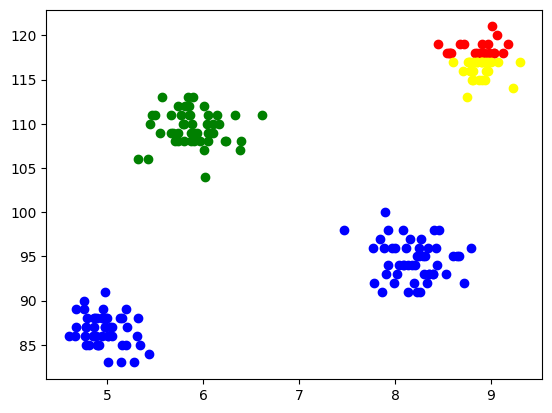

In [10]:
# Visualize the clusters using a scatter plot
# Plot data points belonging to each cluster with a different color
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],c='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],c='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],c='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],c='yellow')
# Display the plot
plt.show()

# **Applying the Clustering Algorithm function on synthetic data**

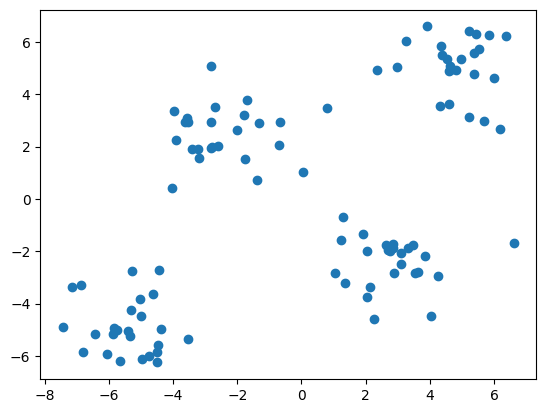

In [12]:
# Define initial centroids and standard deviation for generating synthetic data
centroids = [(-5,-5),(5,5),(-2.5,2.5),(2.5,-2.5)]
cluster_std = [1,1,1,1]

# Generate synthetic data using make_blobs
X,y = make_blobs(n_samples=100,cluster_std=cluster_std,centers=centroids,n_features=2,random_state=2)

# Plot the generated data
plt.scatter(X[:,0],X[:,1])

In [13]:
# Create a KMeans object with 4 clusters and a maximum of 500 iterations for the synthetic data
km = KMeans(n_clusters=4, max_iter=500)

# Fit the model to the synthetic data and predict the cluster assignments
y_means = km.fit_predict(X)

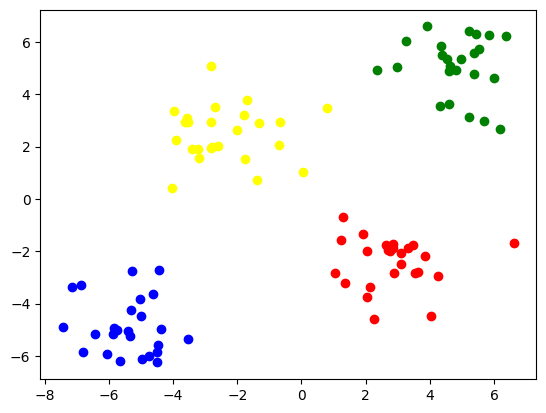

In [14]:
# Visualize the clusters of the synthetic data using a scatter plot
# Plot data points belonging to each cluster with a different color
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],c='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],c='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],c='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],c='yellow')
# Display the plot
plt.show()